In [1]:
# =====================================
# === Block 1: Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from collections import Counter

from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from imblearn.under_sampling import RandomUnderSampler

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# =====================================
# === Block 2: Load Dataset
# =====================================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("Training shape:", df_train.shape)
print("Testing shape :", df_test.shape)
df_train.head()

Training shape: (329623, 13)
Testing shape : (82406, 13)


,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd_sin,wd_cos,PM2.5_level
0,0.140,0.045,0.280,0.184,0.068,0.462,0.578,0.389,0.000,0.136,0.146,0.146,5
1,0.031,0.003,0.021,0.102,0.206,0.667,0.185,0.876,0.031,0.083,0.500,1.000,3
2,0.071,0.055,0.142,0.122,0.022,0.291,0.606,0.385,0.000,0.098,0.854,0.854,2
3,0.070,0.003,0.003,0.020,0.180,0.533,0.368,0.393,0.000,0.159,0.038,0.691,2
4,0.087,0.005,0.311,0.163,0.042,0.665,0.351,0.852,0.000,0.008,0.854,0.146,4


In [3]:
# =====================================
# === Block 3: Split Features/Target
# =====================================
X_train = df_train.drop("PM2.5_level", axis=1)
y_train = df_train["PM2.5_level"]

X_test = df_test.drop("PM2.5_level", axis=1)
y_test = df_test["PM2.5_level"]

print("\nClass distribution (Train):", Counter(y_train))
print("Class distribution (Test):", Counter(y_test))



Class distribution (Train): Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})
Class distribution (Test): Counter({5: 32201, 4: 18265, 1: 16078, 2: 8376, 3: 7486})


In [4]:
# =====================================
# === Block 4: Auto RandomUnderSampler (Smart Reduction Strategy)
# =====================================
class_counts = Counter(y_train)
print("\nBefore UnderSampling:", class_counts)

median_count = np.median(list(class_counts.values()))
max_count = max(class_counts.values())

max_reduction = 0.5  # ลดสูงสุดไม่เกิน 50%
sampling_strategy = {}
for cls, count in class_counts.items():
    if count > median_count:
        ratio = 1 - max_reduction * ((count - median_count) / (max_count - median_count))
        sampling_strategy[cls] = int(count * ratio)
    else:
        sampling_strategy[cls] = count

print("\nAuto Sampling Strategy:", sampling_strategy)

rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

print("After UnderSampling:", Counter(y_resampled))


Before UnderSampling: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})

Auto Sampling Strategy: {5: 64400, 3: 29942, 2: 33504, 4: 68106, 1: 64314}
After UnderSampling: Counter({4: 68106, 5: 64400, 1: 64314, 2: 33504, 3: 29942})


In [5]:
# =====================================
# === Block 5: 10-Fold Cross Validation (Train) + Mean ± SD
# =====================================
print("\n=== 10-Fold Cross Validation Results ===")

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

start_time = time.time()
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_resampled, y_resampled), 1):
    X_tr, X_val = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_tr, y_val = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    model = LinearSVC()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')

    # ROC / AUC (ใช้ decision_function)
    y_val_bin = label_binarize(y_val, classes=np.unique(y_resampled))
    y_score = model.decision_function(X_val)
    auc_score = roc_auc_score(y_val_bin, y_score, average='macro', multi_class='ovr')

    # --- เก็บผล ---
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(auc_score)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, "
          f"F1={f1:.3f}, AUC={auc_score:.3f}")

end_time = time.time()

# ✅ แสดงค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน (Mean ± SD)
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")




=== 10-Fold Cross Validation Results ===
Fold 1: Accuracy=0.629, Precision=0.504, Recall=0.629, F1=0.544, AUC=0.803
Fold 2: Accuracy=0.629, Precision=0.514, Recall=0.629, F1=0.545, AUC=0.802
Fold 3: Accuracy=0.633, Precision=0.508, Recall=0.633, F1=0.548, AUC=0.803
Fold 4: Accuracy=0.631, Precision=0.513, Recall=0.631, F1=0.547, AUC=0.804
Fold 5: Accuracy=0.633, Precision=0.515, Recall=0.633, F1=0.548, AUC=0.802
Fold 6: Accuracy=0.628, Precision=0.503, Recall=0.628, F1=0.543, AUC=0.803
Fold 7: Accuracy=0.630, Precision=0.507, Recall=0.630, F1=0.544, AUC=0.802
Fold 8: Accuracy=0.635, Precision=0.511, Recall=0.635, F1=0.549, AUC=0.805
Fold 9: Accuracy=0.632, Precision=0.508, Recall=0.632, F1=0.547, AUC=0.806
Fold 10: Accuracy=0.631, Precision=0.507, Recall=0.631, F1=0.546, AUC=0.803

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.631 ± 0.002
Precision: 0.509 ± 0.004
Recall   : 0.631 ± 0.002
F1-score : 0.546 ± 0.002
AUC-ROC  : 0.803 ± 0.001

⏱ Completed in 48.87 seconds


In [6]:
# 💾 (Optional) บันทึกค่า Mean ± SD ลงไฟล์ CSV
import os
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/'
summary_path = base_path + "SVM_randomunder_MeanSD.csv"

# ✅ สร้างโฟลเดอร์อัตโนมัติ (กัน error)
os.makedirs(base_path, exist_ok=True)

cv_summary.to_csv(summary_path, index=False)
print(f"💾 Mean + SD summary saved to {summary_path}")

💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/SVM_randomunder_MeanSD.csv


In [7]:
# =====================================
# === Block 6: Train on Full Training Set
# =====================================
model = LinearSVC()
model.fit(X_resampled, y_resampled)
print("✅ Final LinearSVC model trained successfully.")

✅ Final LinearSVC model trained successfully.


In [8]:
# =====================================
# === Block 7: Evaluate on Test Set
# =====================================
y_pred_test = model.predict(X_test)
y_score_test = model.decision_function(X_test)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_test = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=np.unique(y_resampled))
auc_test = roc_auc_score(y_test_bin, y_score_test, average='macro', multi_class='ovr')

print("\n📈 Test Set Metrics:")
print(f"Accuracy={acc_test:.3f}, Precision={prec_test:.3f}, Recall={rec_test:.3f}, F1={f1_test:.3f}, AUC={auc_test:.3f}")

from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


📈 Test Set Metrics:
Accuracy=0.684, Precision=0.591, Recall=0.684, F1=0.618, AUC=0.821

Classification Report:
              precision    recall  f1-score   support

           1       0.64      0.93      0.76     16078
           2       0.23      0.01      0.02      8376
           3       0.00      0.00      0.00      7486
           4       0.51      0.68      0.58     18265
           5       0.85      0.90      0.87     32201

    accuracy                           0.68     82406
   macro avg       0.44      0.50      0.44     82406
weighted avg       0.59      0.68      0.62     82406



Confusion Matrix:
[[14975    23     0   984    96]
 [ 5294    66     0  2894   122]
 [ 2125    67     0  4979   315]
 [  996   115     0 12433  4721]
 [   64    20     1  3235 28881]]


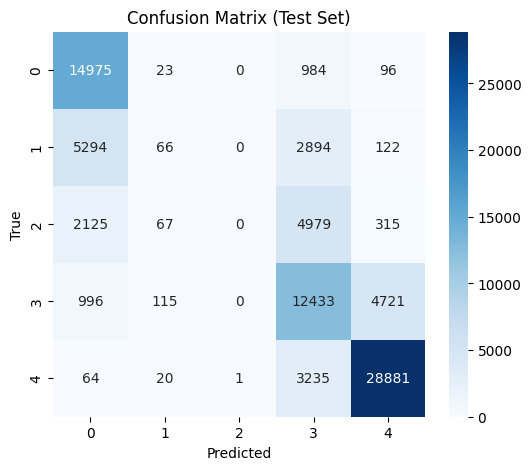

In [9]:
# =====================================
# === Block 8: Confusion Matrix
# =====================================
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

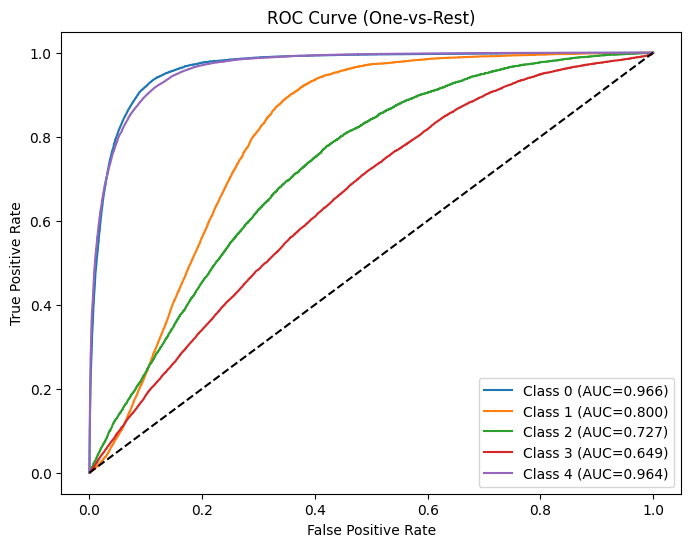

In [ ]:
# =====================================
# === Block 9: ROC Curve (Per-Class)
# =====================================
y_test_bin = label_binarize(y_test, classes=np.unique(y_resampled))
y_score_test = model.decision_function(X_test)

classes = np.unique(y_resampled)
n_classes = len(classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [ ]:
# =====================================
# === Block 10: Save Model & AUC Data
# =====================================
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Senior_Project/roc/randomunder/'

# --- Save Model ---
joblib.dump(model, base_path + 'svm_randomunder.pkl')
print(f"\n💾 Model saved as {base_path}svm_randomunder.pkl")

# --- Save AUC per Fold + Test ---
auc_csv = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [auc_test]
})
auc_csv.to_csv(base_path + 'svm_randomunder_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}svm_randomunder_auc.csv")

# --- Save ROC Curve Data ---
roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})

roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + 'svm_randomunder_roc_points.csv', index=False)
print(f"💾 ROC points saved to {base_path}svm_randomunder_roc_points.csv")

print(f"\n✅ Macro AUC (mean) = {np.mean(list(roc_auc.values())):.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/randomunder/svm_randomunder.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/randomunder/svm_randomunder_auc.csv
💾 ROC points saved to /content/drive/MyDrive/Senior_Project/roc/randomunder/svm_randomunder_roc_points.csv

✅ Macro AUC (mean) = 0.8211
